In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("4.loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


handle missing values



In [4]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns #instead of float64 or int we can write "number" for numerical values

In [5]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [6]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [7]:
# imputer
# Replace missing values using a descriptive statistic 
# (e.g. mean, median, or most frequent) along each column, 
# or using a constant value.

from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [9]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

EDA- exploratory data analysis

Text(0.5, 1.0, 'is loan approved or not ')

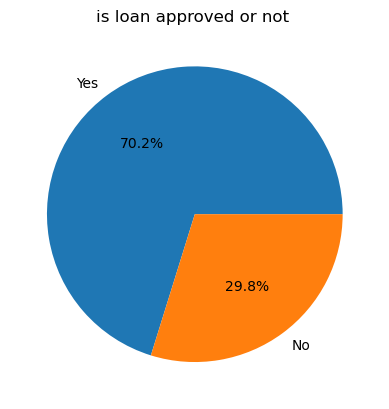

In [10]:
# how balance is our classes
classes_count=df["Loan_Approved"].value_counts()

plt.pie(classes_count,labels=["Yes","No"],autopct="%1.1f%%")
plt.title("is loan approved or not ")

[Text(0, 0, '722'), Text(0, 0, '278')]

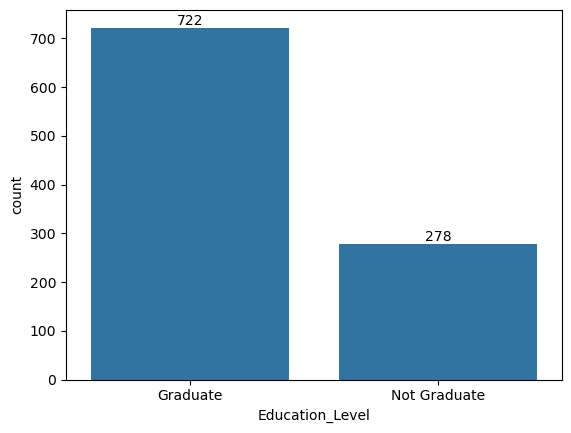

In [11]:
# analyze categories

# gender_cnt=df["Gender"].value_counts()
# ax=sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

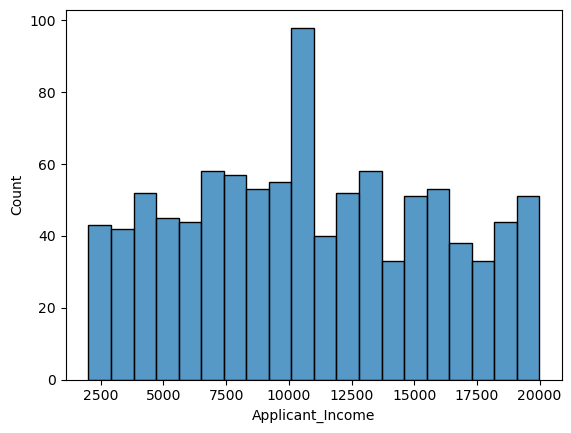

In [12]:
# analyze income
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

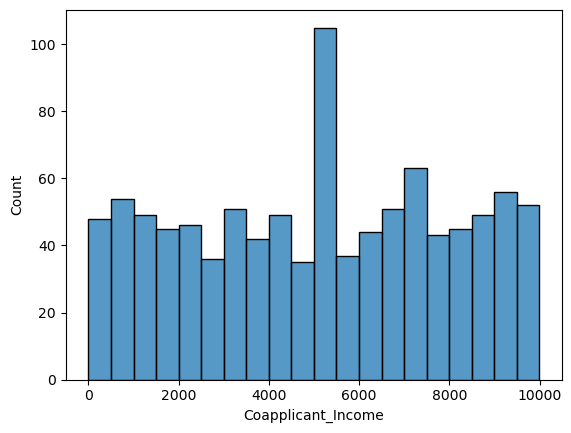

In [13]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

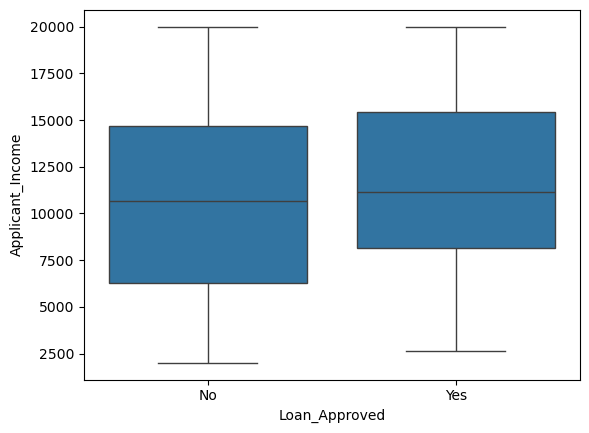

In [14]:
# outliers-box plots
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income",
)

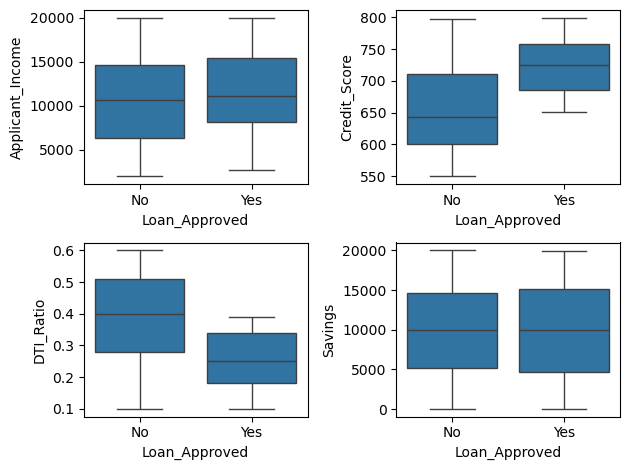

In [15]:
fig,axes =plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

plt.tight_layout()


<Axes: xlabel='Credit_Score', ylabel='Count'>

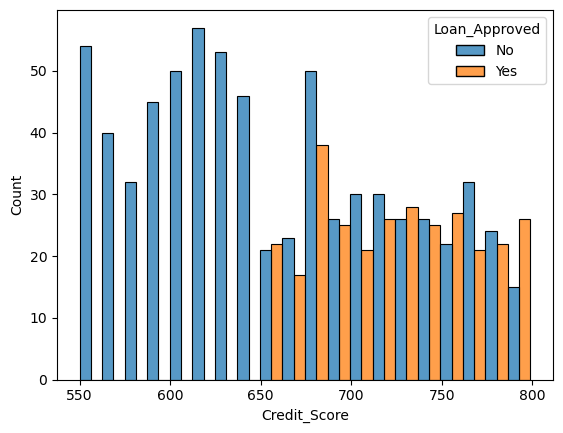

In [16]:
# 
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

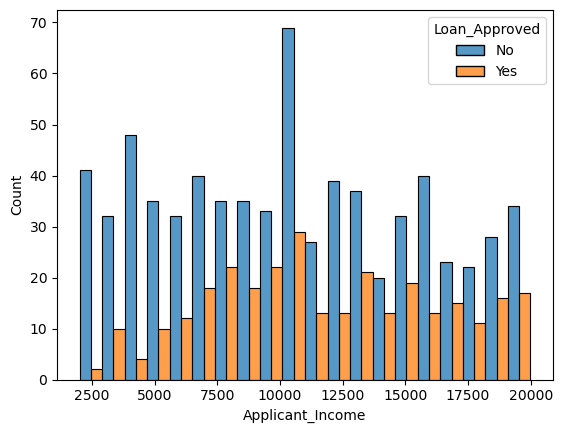

In [17]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [18]:
# Remove applicant id because it is not much important
df=df.drop("Applicant_ID",axis=1)

Encoding

In [19]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [20]:
# Encoding
# · LabelEncoder - Assigns an integer to each category.
# . OneHotEncoder - Creates binary columns for each category.

from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


In [21]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [22]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [23]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


Correlation Heat Map

In [24]:
# Correlation Heatmap
# It is a visual representation of the relationships between numerical variables in a dataset.
# It shows Correlation coefficient (r) between two numeric variables
# · ranges from -1 to 1
# · 1 is perfect positive correlation
# .-1 is perfect negative correlation
# · O is no linear correlation

<Axes: >

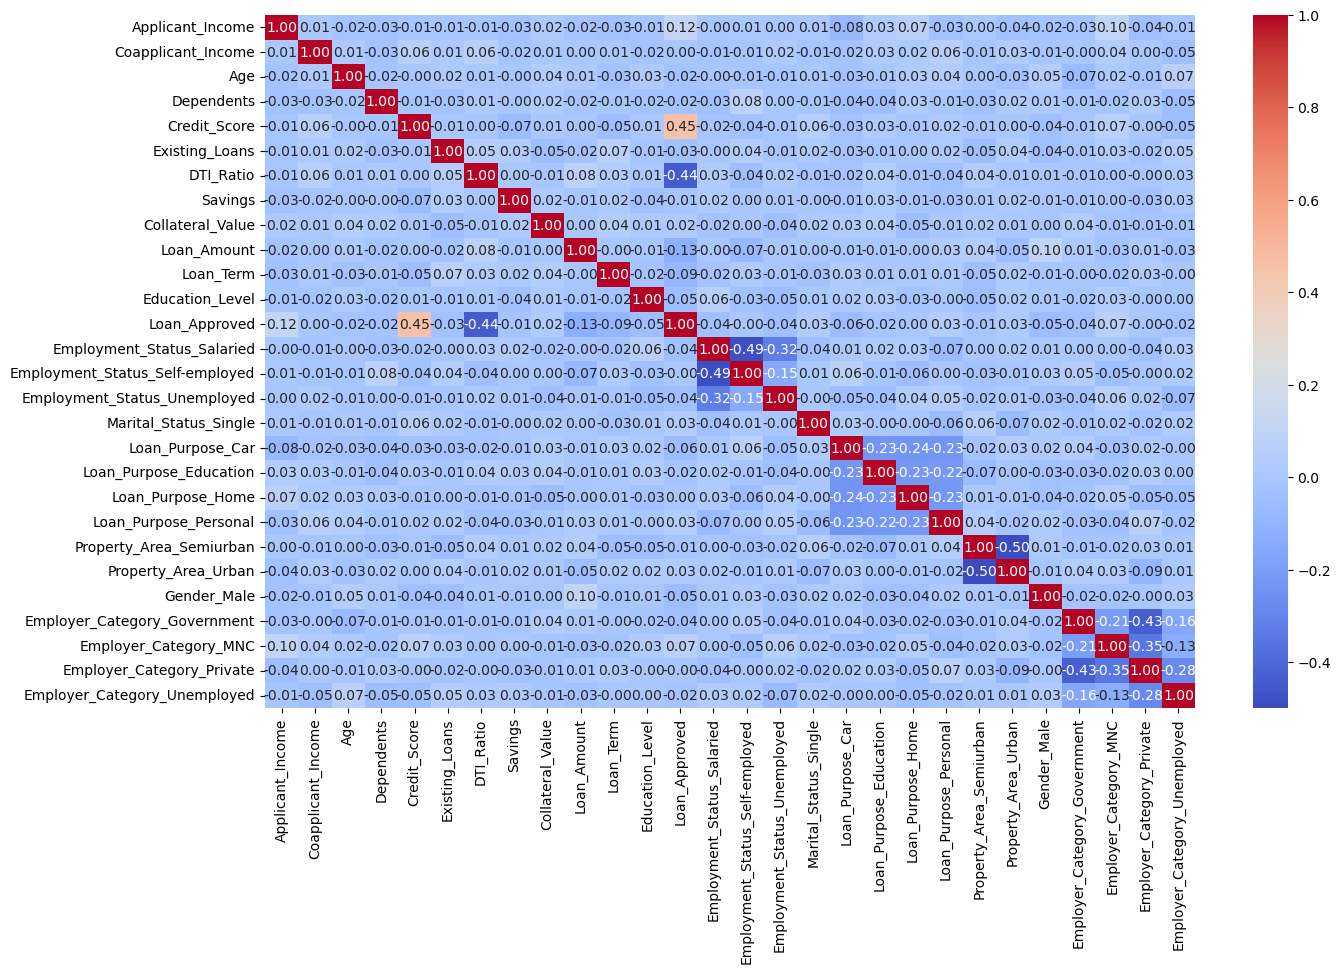

In [32]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

plt.figure(figsize=(15,9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [30]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

TRAIN TEST -SPLIT AND FEATURE SCALING

In [33]:
X=df.drop(columns="Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [36]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [38]:
y_train.head()

29     0
535    0
695    0
557    0
836    1
Name: Loan_Approved, dtype: int64

In [41]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [43]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

In [46]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.7833333333333333
accuracy 0.865
recall 0.7704918032786885
f1 0.7768595041322314
confision [[126  13]
 [ 14  47]]


In [50]:
# knn classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.5737704918032787
accuracy 0.74
recall 0.5737704918032787
f1 0.5737704918032787
confision [[113  26]
 [ 26  35]]


In [51]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.8035714285714286
accuracy 0.865
recall 0.7377049180327869
f1 0.7692307692307693
confision [[128  11]
 [ 16  45]]


BEST MODEL ON THE BASIS OF PRECISION=>NAIVE BAYES

FEATURE ENGINEERING

In [54]:
#add or transform features
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

df["Applicant_Income"]=np.log1p(df["Applicant_Income"])

X=df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"])
y=df["Loan_Approved"]

# train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

#scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [56]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred=log_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.7903225806451613
accuracy 0.875
recall 0.8032786885245902
f1 0.7967479674796748
confision [[126  13]
 [ 12  49]]


In [57]:
# knn classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled,y_train)

y_pred=knn_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.5671641791044776
accuracy 0.74
recall 0.6229508196721312
f1 0.59375
confision [[110  29]
 [ 23  38]]


In [58]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,precision_score,accuracy_score,recall_score,f1_score
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred=nb_model.predict(X_test_scaled)

print("precision",precision_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1",f1_score(y_test,y_pred))
print("confision",confusion_matrix(y_test,y_pred))



precision 0.8
accuracy 0.86
recall 0.7213114754098361
f1 0.7586206896551724
confision [[128  11]
 [ 17  44]]
